In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, random_split
import matplotlib.pyplot as plt


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
import torchvision.transforms.functional as TF

class BraTSDataset(Dataset):
    def __init__(self, img_dir, mask_dir, augment=False):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.augment = augment

        self.imgs = sorted([f for f in os.listdir(img_dir) if f.endswith(".npy")])
        self.masks = sorted([f for f in os.listdir(mask_dir) if f.endswith(".npy")])

        common = sorted(set(self.imgs) & set(self.masks))
        self.imgs = common
        self.masks = common

        print("✔ Total paired slices:", len(self.imgs))

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = np.load(os.path.join(self.img_dir, self.imgs[idx]))
        mask = np.load(os.path.join(self.mask_dir, self.masks[idx]))

        if img.ndim == 3:
            img = img.mean(axis=-1)

        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
        mask = (mask > 0).float()

        # 🔹 LIGHT augmentation (SAFE)
        if self.augment:
            if random.random() < 0.5:
                img = TF.hflip(img)
                mask = TF.hflip(mask)

            if random.random() < 0.5:
                img = TF.vflip(img)
                mask = TF.vflip(mask)

            angle = random.uniform(-10, 10)
            img = TF.rotate(img, angle)
            mask = TF.rotate(mask, angle)

        return img, mask

In [ ]:
IMG_DIR  = "/content/drive/MyDrive/Brats20_Project/Reduced/images"
MASK_DIR = "/content/drive/MyDrive/Brats20_Project/Reduced/masks"

dataset = BraTSDataset(IMG_DIR, MASK_DIR)

indices = list(range(len(dataset)))
random.shuffle(indices)

subset_indices = indices[:3000]   # 🔥 slightly more data than before
subset_dataset = Subset(dataset, subset_indices)

print("Training slices:", len(subset_dataset))

✔ Total paired slices: 8536
Training slices: 3000


In [ ]:
val_size = int(0.2 * len(subset_dataset))
train_size = len(subset_dataset) - val_size

train_ds, val_ds = random_split(subset_dataset, [train_size, val_size])

seg_train_loader = DataLoader(
    train_ds,
    batch_size=16,     # ✅ increased safely
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train:", len(train_ds), " Val:", len(val_ds))

Train: 2400  Val: 600


In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class AttentionBlock(nn.Module):
    def __init__(self, g_ch, x_ch, int_ch):
        super().__init__()
        self.Wg = nn.Conv2d(g_ch, int_ch, 1)
        self.Wx = nn.Conv2d(x_ch, int_ch, 1)
        self.psi = nn.Conv2d(int_ch, 1, 1)

    def forward(self, g, x):
        psi = torch.sigmoid(self.psi(F.relu(self.Wg(g) + self.Wx(x))))
        return x * psi


class AttentionUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.c1 = DoubleConv(1, 64)
        self.c2 = DoubleConv(64, 128)
        self.c3 = DoubleConv(128, 256)
        self.c4 = DoubleConv(256, 512)

        self.p = nn.MaxPool2d(2)

        self.u3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.a3 = AttentionBlock(256, 256, 128)
        self.uc3 = DoubleConv(512, 256)

        self.u2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.a2 = AttentionBlock(128, 128, 64)
        self.uc2 = DoubleConv(256, 128)

        self.u1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.a1 = AttentionBlock(64, 64, 32)
        self.uc1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        x1 = self.c1(x)
        x2 = self.c2(self.p(x1))
        x3 = self.c3(self.p(x2))
        x4 = self.c4(self.p(x3))

        d3 = self.u3(x4)
        d3 = self.uc3(torch.cat([self.a3(d3, x3), d3], 1))

        d2 = self.u2(d3)
        d2 = self.uc2(torch.cat([self.a2(d2, x2), d2], 1))

        d1 = self.u1(d2)
        d1 = self.uc1(torch.cat([self.a1(d1, x1), d1], 1))

        return self.out(d1)

In [ ]:
def dice_score(logits, targets, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    inter = (preds * targets).sum((1,2,3))
    union = preds.sum((1,2,3)) + targets.sum((1,2,3))

    return ((2 * inter + eps) / (union + eps)).mean()


class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        return 0.5 * self.bce(logits, targets) + 0.5 * (1 - dice_score(logits, targets))

In [ ]:
model = AttentionUNet().to(device)

criterion = DiceBCELoss()   # ✅ changed
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scaler = torch.cuda.amp.GradScaler()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=1
)

/tmp/ipython-input-1147914929.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
EPOCHS = 5
MAX_BATCHES = 300

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    for i, (imgs, masks) in enumerate(seg_train_loader):
        if i >= MAX_BATCHES:
            break

        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast():
            outputs = model(imgs)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / MAX_BATCHES
    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f}")

/tmp/ipython-input-801837390.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1 | Loss: 0.3306
Epoch 2 | Loss: 0.2591
Epoch 3 | Loss: 0.1947
Epoch 4 | Loss: 0.1813
Epoch 5 | Loss: 0.1585


In [ ]:
val_size = int(0.2 * len(dataset))
train_size = len(dataset) - val_size

_, val_dataset = random_split(dataset, [train_size, val_size])

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

model.eval()
dice_total = 0.0
MAX_VAL_BATCHES = 100

with torch.no_grad():
    for i, (imgs, masks) in enumerate(val_loader):
        if i >= MAX_VAL_BATCHES:
            break

        imgs = imgs.to(device)
        masks = masks.to(device)

        outputs = model(imgs)
        dice_total += dice_score(outputs, masks).item()

avg_dice = dice_total / MAX_VAL_BATCHES
scheduler.step(avg_dice)

print(f"✅ Validation Dice: {avg_dice:.4f}")

✅ Validation Dice: 0.5336


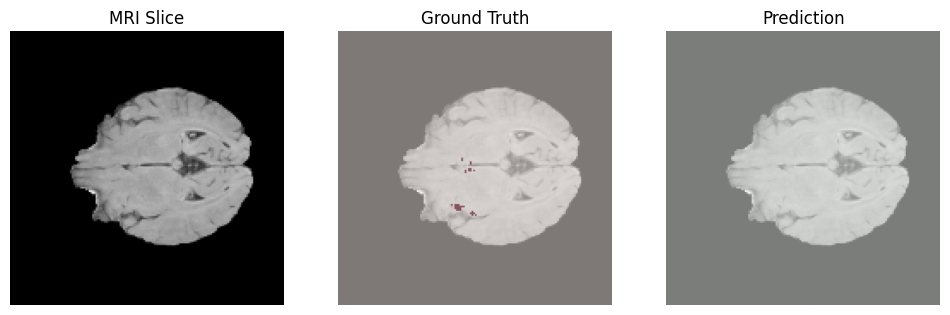

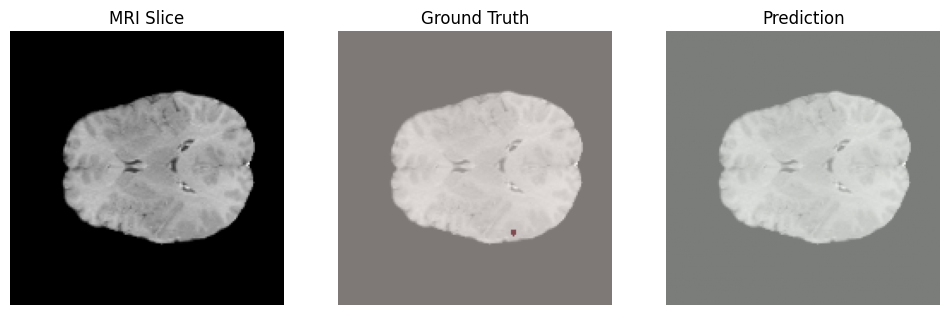

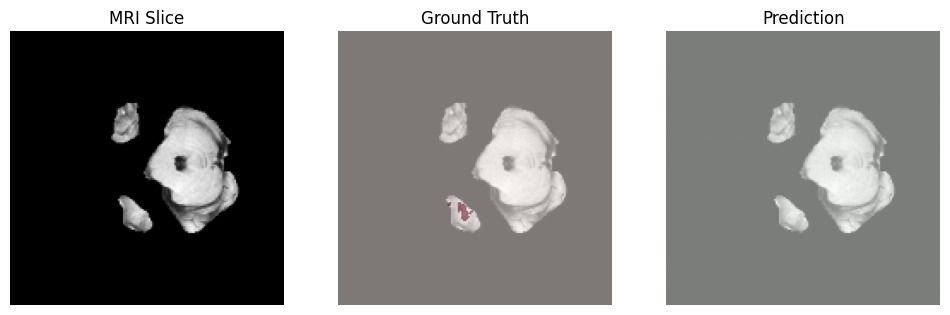

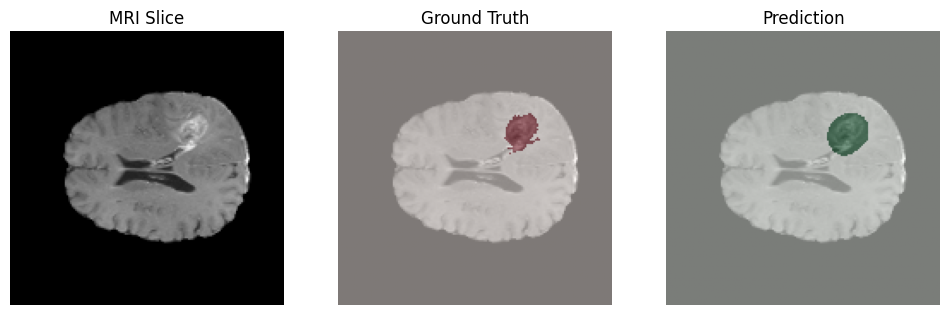

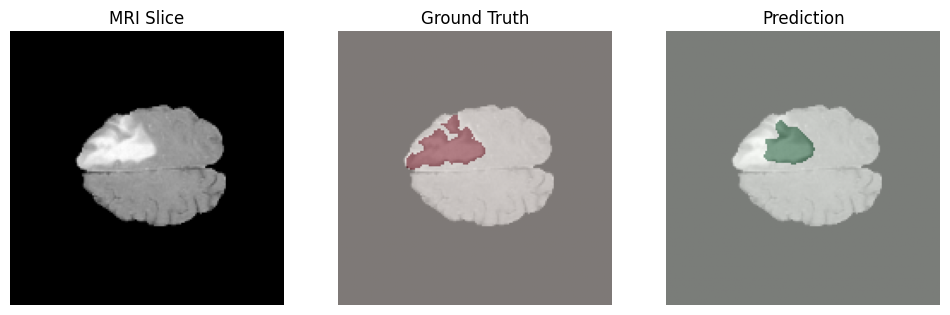

In [ ]:
def visualize_prediction(model, loader, device, num_samples=3):
    model.eval()
    shown = 0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            logits = model(imgs)
            preds = (torch.sigmoid(logits) > 0.5).float()

            for i in range(imgs.size(0)):
                if shown >= num_samples:
                    return

                img = imgs[i, 0].cpu()
                gt  = masks[i, 0].cpu()
                pr  = preds[i, 0].cpu()

                plt.figure(figsize=(12,4))

                plt.subplot(1,3,1)
                plt.title("MRI Slice")
                plt.imshow(img, cmap="gray")
                plt.axis("off")

                plt.subplot(1,3,2)
                plt.title("Ground Truth")
                plt.imshow(img, cmap="gray")
                plt.imshow(gt, alpha=0.5, cmap="Reds")
                plt.axis("off")

                plt.subplot(1,3,3)
                plt.title("Prediction")
                plt.imshow(img, cmap="gray")
                plt.imshow(pr, alpha=0.5, cmap="Greens")
                plt.axis("off")

                plt.show()
                shown += 1

visualize_prediction(model, val_loader, device, num_samples=5)

In [ ]:
model.eval()

total_tp = 0
total_fp = 0
total_fn = 0
total_tn = 0

MAX_VAL_BATCHES_METRICS = len(val_loader) # Use entire validation set or a subset

with torch.no_grad():
    for i, (imgs, masks) in enumerate(val_loader):
        if i >= MAX_VAL_BATCHES_METRICS:
            break

        imgs = imgs.to(device)
        masks = masks.to(device)

        logits = model(imgs)
        preds = (torch.sigmoid(logits) > 0.5).float()

        # Flatten tensors for easier pixel-wise comparison
        preds_flat = preds.view(-1)
        masks_flat = masks.view(-1)

        # Calculate TP, FP, FN, TN
        tp = ((preds_flat == 1) & (masks_flat == 1)).sum().item()
        fp = ((preds_flat == 1) & (masks_flat == 0)).sum().item()
        fn = ((preds_flat == 0) & (masks_flat == 1)).sum().item()
        tn = ((preds_flat == 0) & (masks_flat == 0)).sum().item()

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_tn += tn

# Calculate metrics based on aggregated counts
epsilon = 1e-7 # Small epsilon to avoid division by zero

precision = total_tp / (total_tp + total_fp + epsilon)
recall = total_tp / (total_tp + total_fn + epsilon)
f1_score = (2 * precision * recall) / (precision + recall + epsilon)

print(f"\n--- Segmentation Metrics ---")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score (Dice): {f1_score:.4f}")

# Optionally, print confusion matrix components
print(f"\nConfusion Matrix Components (Pixel-wise):")
print(f"True Positives (TP): {total_tp}")
print(f"False Positives (FP): {total_fp}")
print(f"False Negatives (FN): {total_fn}")
print(f"True Negatives (TN): {total_tn}")



--- Segmentation Metrics ---
Precision: 0.8032
Recall: 0.5798
F1-score (Dice): 0.6735

Confusion Matrix Components (Pixel-wise):
True Positives (TP): 529305
False Positives (FP): 129688
False Negatives (FN): 383600
True Negatives (TN): 42656607


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/Brats20_Project/models"
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH = SAVE_DIR + "/attention_unet_3000_aug.pth"
torch.save(model.state_dict(), MODEL_PATH)
print("model saved permanently to drive")

model saved permanently to drive


In [ ]:
# Ensure model and optimizer are initialized, especially after a kernel restart
if 'model' not in locals() or not isinstance(model, AttentionUNet):
    print("Model not found or not initialized as AttentionUNet. Re-initializing AttentionUNet.")
    try:
        model = AttentionUNet().to(device)
    except NameError as e:
        print(f"Error initializing AttentionUNet: {e}. Please ensure 'AttentionUNet' class and 'device' are defined by running prior cells.")
        raise
if 'optimizer' not in locals():
    print("Optimizer not found. Re-initializing Adam optimizer with default learning rate.")
    try:
        # Re-using the learning rate from initial optimizer setup (1e-4 from cell ImIPRNtJGw07)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    except NameError as e:
        print(f"Error initializing optimizer: {e}. Please ensure 'model' is defined.")
        raise

# Load the checkpoint using the correct full path
try:
    # MODEL_PATH variable is defined
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    print(f"Checkpoint loaded successfully from {MODEL_PATH}.")
    model.load_state_dict(checkpoint)
    print(f"Model state loaded successfully from {MODEL_PATH}.")


except FileNotFoundError:
    print(f"Error: Checkpoint file not found at {MODEL_PATH}.")
    print("Please ensure the path is correct and the file exists on Google Drive.")
    raise
except Exception as e:
    print(f"An unexpected error occurred during checkpoint loading: {e}")
    raise

model.eval()
print("Model set to evaluation mode.")


Checkpoint loaded successfully from /content/drive/MyDrive/Brats20_Project/models/attention_unet_3000_aug.pth.
Model state loaded successfully from /content/drive/MyDrive/Brats20_Project/models/attention_unet_3000_aug.pth.
Model set to evaluation mode.


In [ ]:
import torchvision.transforms as T

clf_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(10),
    T.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])


In [ ]:
!find /content/drive/MyDrive -name "*.pth"

/content/drive/MyDrive/Brats20_Project/models/attention_unet_3000_aug.pth


In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models
from torchvision import transforms
import torchvision.transforms.functional as TF
from PIL import Image

In [ ]:
model = AttentionUNet().to(device)
checkpoint = torch.load(
    "/content/drive/MyDrive/Brats20_Project/models/attention_unet_3000_aug.pth",
    map_location=device
)
model.load_state_dict(checkpoint)

model.eval()

for p in model.parameters():
    p.requires_grad = False



In [ ]:
# COMPUTE LABELS CLEANLY (NO CACHE)

IMG_DIR  = "/content/drive/MyDrive/Brats20_Project/Reduced/images"
MASK_DIR = "/content/drive/MyDrive/Brats20_Project/Reduced/masks"

files = [
    f for f in os.listdir(MASK_DIR)
    if f.endswith(".npy")
]

labels = []

for f in files:
    mask = np.load(os.path.join(MASK_DIR, f))
    area = mask.sum()

    if area == 0:
        labels.append(0)        # No tumor
    elif area < 500:
        labels.append(1)        # Low grade
    else:
        labels.append(2)        # High grade

labels = np.array(labels, dtype=np.int64)

print("Labels generated")
print("Shape:", labels.shape)
print("Class counts:", np.bincount(labels))

Labels generated
Shape: (8536,)
Class counts: [1786 1866 4884]


In [ ]:
SAVE_PATH = "/content/drive/MyDrive/Brats20_Project/Reduced/labels.npy"

np.save(SAVE_PATH, labels)

print("Labels saved at:", SAVE_PATH)
print("Shape:", labels.shape)
print("Unique labels:", np.unique(labels))

In [ ]:
from torch.utils.data import WeightedRandomSampler
labels = np.load(
    "/content/drive/MyDrive/Brats20_Project/Reduced/labels.npy"
)

labels = labels.astype(np.int64)

class_count = np.bincount(labels)
print("Class count:", class_count)

class_weights = 1. / class_count
sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

Class count: [1786 1866 4884]


In [ ]:
from torch.utils.data import Dataset
import torchvision.transforms.functional as TF
from PIL import Image

class TumorClassificationDataset(Dataset):
    def __init__(self, img_dir, mask_dir, augment=True):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.augment = augment

        # ✅ CRITICAL FIX: use only common files
        img_files  = set(f for f in os.listdir(img_dir) if f.endswith(".npy"))
        mask_files = set(f for f in os.listdir(mask_dir) if f.endswith(".npy"))
        self.files = sorted(img_files & mask_files)

        assert len(self.files) > 0, "No matching image-mask pairs found!"

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]

        img  = np.load(os.path.join(self.img_dir, fname))
        mask = np.load(os.path.join(self.mask_dir, fname))

        # ---- Convert 3D → 2D if needed ----
        if img.ndim == 3:
            img = img.mean(axis=-1)

        # ---- ROI extraction using segmentation mask ----
        if mask.sum() > 0:
            ys, xs = np.where(mask > 0)
            roi = img[ys.min():ys.max()+1, xs.min():xs.max()+1]
        else:
            roi = img  # no tumor → full slice

        # ---- Resize ----
        roi = np.array(Image.fromarray(roi).resize((160, 160)))

        # ---- Tensor + channel fix for ResNet ----
        roi = torch.tensor(roi, dtype=torch.float32)
        roi = roi.unsqueeze(0)       # [1, H, W]
        roi = roi.repeat(3, 1, 1)    # [3, H, W]

        # ---- Rule-based grading ----
        area = mask.sum()
        if area == 0:
            label = 0        # No tumor
        elif area < 500:
            label = 1        # Low grade
        else:
            label = 2        # High grade

        # ---- Augmentation ----
        if self.augment:
            if random.random() < 0.5:
                roi = TF.hflip(roi)
            if random.random() < 0.5:
                roi = TF.vflip(roi)
            roi = TF.rotate(roi, random.uniform(-10, 10))

        return roi, label

In [ ]:
IMG_DIR  = "/content/drive/MyDrive/Brats20_Project/Reduced/images"
MASK_DIR = "/content/drive/MyDrive/Brats20_Project/Reduced/masks"

train_dataset = TumorClassificationDataset(
    IMG_DIR,
    MASK_DIR,
    augment=True
)

cls_train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    sampler=sampler,
    num_workers=8,
    pin_memory=True
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
import torch.nn as nn
from torchvision import models
class HybridClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet50(pretrained=True)

        for p in self.backbone.parameters():
            p.requires_grad = False

        # Save feature dimension BEFORE fc
        self.feature_dim = self.backbone.fc.in_features

        # Remove original FC
        self.backbone.fc = nn.Identity()

        # New classifier head
        self.classifier = nn.Sequential(
            nn.Linear(self.feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 3)
        )

    def forward(self, x, return_feature=False):
        features = self.backbone(x)        # [B, 2048]
        logits = self.classifier(features) # [B, 3]

        if return_feature:
            return features, logits
        return logits

In [ ]:
clf_model = HybridClassifier().to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(clf_model.parameters(), lr=1e-4)

In [ ]:
EPOCHS = 10

for epoch in range(EPOCHS):
    clf_model.train()
    total_loss = 0
    correct = 0
    total = 0

    for imgs, labels_batch in cls_train_loader:
        imgs = imgs.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = clf_model(imgs)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(1)
        correct += (preds == labels_batch).sum().item()
        total += labels_batch.size(0)

    acc = correct / total
    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {total_loss/len(cls_train_loader):.4f} | "
        f"Accuracy: {acc:.4f}"
    )

Epoch 1/10 | Loss: 0.2929 | Accuracy: 0.8848
Epoch 2/10 | Loss: 0.2063 | Accuracy: 0.9128
Epoch 3/10 | Loss: 0.2117 | Accuracy: 0.9093
Epoch 4/10 | Loss: 0.1960 | Accuracy: 0.9185
Epoch 5/10 | Loss: 0.1910 | Accuracy: 0.9190
Epoch 6/10 | Loss: 0.1968 | Accuracy: 0.9155
Epoch 7/10 | Loss: 0.2062 | Accuracy: 0.9099
Epoch 8/10 | Loss: 0.1801 | Accuracy: 0.9248
Epoch 9/10 | Loss: 0.1883 | Accuracy: 0.9187
Epoch 10/10 | Loss: 0.1824 | Accuracy: 0.9230


In [ ]:
CLF_SAVE_DIR = "/content/drive/MyDrive/Brats20_Project/models"
os.makedirs(CLF_SAVE_DIR, exist_ok=True)

CLF_MODEL_PATH = os.path.join(CLF_SAVE_DIR, "hybrid_classifier.pth")
torch.save(clf_model.state_dict(), CLF_MODEL_PATH)
print(f"Classification model saved to: {CLF_MODEL_PATH}")

Classification model saved to: /content/drive/MyDrive/Brats20_Project/models/hybrid_classifier.pth


In [ ]:
# ─── CREATE VALIDATION SPLIT + RUN EVALUATION ─────────────────────────────────

from torch.utils.data import random_split, DataLoader
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# 1️⃣ Create full dataset without augmentation (for validation)
full_dataset = TumorClassificationDataset(
    IMG_DIR,
    MASK_DIR,
    augment=False   # no augmentation for val
)

# 2️⃣ Split into train + val (20% val)
total_len = len(full_dataset)
val_len = int(0.2 * total_len)
train_len = total_len - val_len

train_dataset, val_dataset = random_split(
    full_dataset, [train_len, val_len]
)

# 3️⃣ Create validation DataLoader
val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# 4️⃣ Evaluate model on validation set
y_true, y_pred = [], []

clf_model.eval()

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = clf_model(imgs)
        preds = outputs.argmax(1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 5️⃣ Print metrics
print("Classification Report:\n")
print(classification_report(y_true, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_true, y_pred))

print("Precision:", precision_score(y_true, y_pred, average="weighted"))
print("Recall:", recall_score(y_true, y_pred, average="weighted"))
print("F1 Score:", f1_score(y_true, y_pred, average="weighted"))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       353
           1       0.95      0.77      0.85       381
           2       0.92      0.98      0.95       973

    accuracy                           0.94      1707
   macro avg       0.95      0.92      0.93      1707
weighted avg       0.94      0.94      0.94      1707

Confusion Matrix:

[[353   0   0]
 [  0 293  88]
 [  0  17 956]]
Precision: 0.9397136062931489
Recall: 0.9384885764499121
F1 Score: 0.9364110636439485


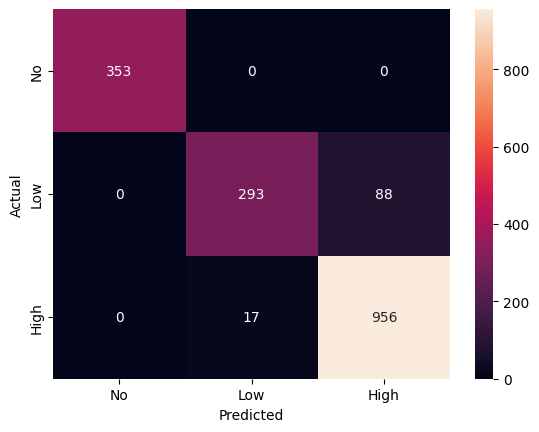

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=["No", "Low", "High"],
    yticklabels=["No", "Low", "High"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
CLF_SAVE_DIR = "/content/drive/MyDrive/Brats20_Project/models"
os.makedirs(CLF_SAVE_DIR, exist_ok=True)

CLF_MODEL_PATH = os.path.join(CLF_SAVE_DIR, "hybrid_classifier.pth")
CLF_OPT_PATH   = os.path.join(CLF_SAVE_DIR, "optimizer.pth")

# Save model + optimizer states
torch.save({
    "model_state_dict": clf_model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
}, CLF_MODEL_PATH)

print(f"Model + optimizer saved to: {CLF_MODEL_PATH}")


In [ ]:
clf_model = HybridClassifier().to(device)

state = torch.load(
    "/content/drive/MyDrive/Brats20_Project/models/hybrid_classifier.pth",
    map_location=device
)

clf_model.load_state_dict(state, strict=False)
clf_model.eval()

print("✅ Classification model loaded successfully")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ Classification model loaded successfully


In [ ]:
import inspect
print(inspect.signature(clf_model.forward))

(x, return_feature=False)


In [ ]:
x = torch.randn(2, 3, 224, 224).to(device)
feats, out = clf_model(x, return_feature=True)

print(feats.shape, out.shape)

torch.Size([2, 2048]) torch.Size([2, 3])


In [ ]:
import time

features = []
labels = []
start_all = time.time()
batch_time = time.time()

with torch.no_grad():
    for idx, (imgs, lbls) in enumerate(cls_train_loader):
        feats, _ = clf_model(imgs.to(device), return_feature=True)
        features.append(feats.cpu())
        labels.append(lbls)

        if idx % 50 == 0:  # change number as you like
            print(f"Processed {idx} batches. Time for last 50: {time.time() - batch_time:.2f}s")
            batch_time = time.time()

X = torch.cat(features).numpy()
y = torch.cat(labels).numpy()

print("Done! Total time:", time.time() - start_all)
print(X.shape, y.shape)


Processed 0 batches. Time for last 50: 13.41s
Processed 50 batches. Time for last 50: 64.73s
Processed 100 batches. Time for last 50: 62.07s
Processed 150 batches. Time for last 50: 54.29s
Processed 200 batches. Time for last 50: 55.69s
Processed 250 batches. Time for last 50: 45.51s
Processed 300 batches. Time for last 50: 44.29s
Processed 350 batches. Time for last 50: 36.47s
Processed 400 batches. Time for last 50: 31.46s
Processed 450 batches. Time for last 50: 29.68s
Processed 500 batches. Time for last 50: 34.50s
Done! Total time: 490.4667959213257
(8536, 2048) (8536,)


In [ ]:
tumor_features = []

for f in os.listdir("/content/drive/MyDrive/Brats20_Project/Reduced/masks"):
    if not f.endswith(".npy"):
        continue

    mask = np.load("/content/drive/MyDrive/Brats20_Project/Reduced/masks/" + f)

    volume = mask.sum()
    area_ratio = volume / mask.size

    tumor_features.append([volume, area_ratio])

tumor_features = np.array(tumor_features)


In [ ]:
X_fused = np.concatenate([X, tumor_features], axis=1)
print(X_fused.shape)

(8536, 2050)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_fused, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

rf.fit(X_train, y_train)

preds = rf.predict(X_test)
print("Survival / Grade Accuracy:", accuracy_score(y_test, preds))


Survival / Grade Accuracy: 0.90807962529274


In [ ]:
import joblib
# Save the trained random forest model
joblib.dump(rf, "/content/drive/MyDrive/Brats20_Project/survival_model.pkl")
print("Survival model saved to /content/drive/MyDrive/Brats20_Project/survival_model.pkl")


Survival model saved to /content/drive/MyDrive/Brats20_Project/survival_model.pkl


In [ ]:
import joblib

survival_model_path = "/content/drive/MyDrive/Brats20_Project/survival_model.pkl"

# Load the survival model
survival_model = joblib.load(survival_model_path)

print("Survival model loaded successfully!")


Survival model loaded successfully!


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       366
           1       0.88      0.67      0.76       389
           2       0.88      0.96      0.92       953

    accuracy                           0.90      1708
   macro avg       0.92      0.88      0.89      1708
weighted avg       0.90      0.90      0.90      1708

Confusion Matrix:
 [[366   0   0]
 [  0 260 129]
 [  0  35 918]]


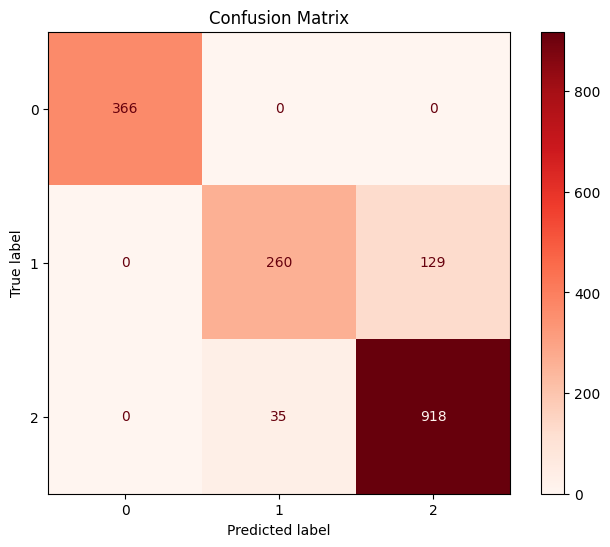

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, preds)
print("Classification Report:\n", classification_report(y_test, preds))
print("Confusion Matrix:\n", cm)

# Create a plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap=plt.cm.Reds)  # You can choose any colormap
ax.set_title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()


In [ ]:
!pip install captum


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 133.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.36.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 

In [ ]:
!pip install grad-cam

  Using cached grad-cam-1.5.5.tar.gz (7.8 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 139.8 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=56fcc1cbe1b759768d527cdf45eb61c7117a3b34b53eed440ec693c8e4652b79
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
captum 0.8.0 requires numpy<2.0, but you hav

Enter MRI filename : /content/drive/MyDrive/Brats20_Project/Reduced/images/1217.npy
Predicted class: 0


/usr/local/lib/python3.12/dist-packages/captum/attr/_core/guided_backprop_deconvnet.py:63: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


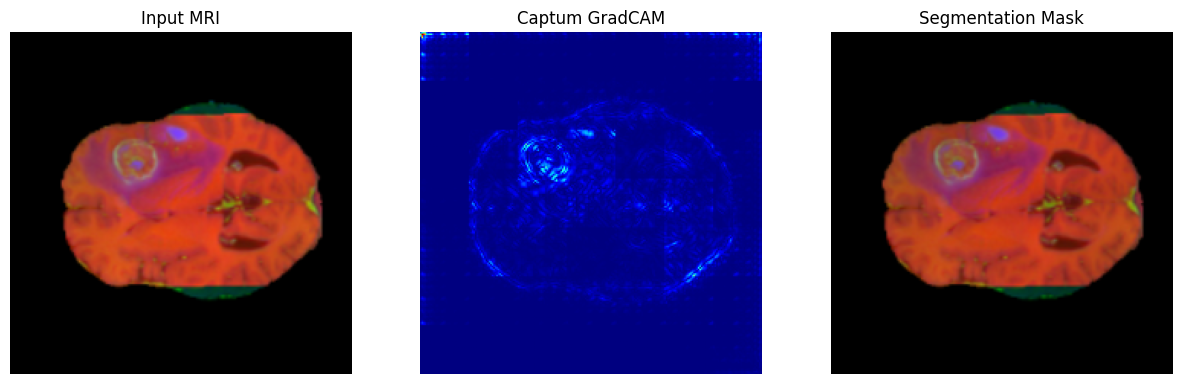

In [ ]:
%matplotlib inline
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms

from captum.attr import GuidedGradCam
from pytorch_grad_cam.utils.image import show_cam_on_image

# === MODEL SETUP ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
clf_model.to(device)
clf_model.eval()

# === PATHS ===
img_dir  = "/content/drive/MyDrive/Brats20_Project/Reduced/images"
mask_dir = "/content/drive/MyDrive/Brats20_Project/Reduced/masks"

# === PICK ONE IMAGE ===
fname = input("Enter MRI filename : ").strip()

img_path  = os.path.join(img_dir, fname)
mask_path = os.path.join(mask_dir, fname)

if not os.path.exists(img_path):
    raise FileNotFoundError(f"{fname} not found in images folder")

if not os.path.exists(mask_path):
    raise FileNotFoundError(f"{fname} not found in masks folder")

# === LOAD & NORMALIZE ===
img_np = np.load(os.path.join(img_dir, fname))  # (160,160,3)
img_norm = (img_np - img_np.min())/(img_np.max() - img_np.min() + 1e-8)
rgb_resized = cv2.resize(img_norm, (224,224))

# === PREPROCESS ===
transform = transforms.Compose([
    transforms.ToTensor(),  # float32 by default
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# create float tensor
input_tensor = transform(rgb_resized).unsqueeze(0).to(device).float()

# === PREDICT ===
output = clf_model(input_tensor)  # no dtype mismatch now
pred_class = output.argmax(dim=1).item()
print("Predicted class:", pred_class)

# === CAPTUM GRADCAM ===
guided_gc = GuidedGradCam(clf_model, clf_model.backbone.layer4[-1])

# compute attribution
attribution = guided_gc.attribute(input_tensor, target=pred_class)

# convert to heatmap
heatmap = attribution.detach().cpu().numpy()[0].transpose(1,2,0)
heatmap = np.mean(np.abs(heatmap), axis=-1)
heatmap /= (heatmap.max() + 1e-8)

heatmap_rgb = cv2.applyColorMap(
    np.uint8(255*heatmap), cv2.COLORMAP_JET)
heatmap_rgb = cv2.cvtColor(heatmap_rgb, cv2.COLOR_BGR2RGB)/255.0

# === SEGMENTATION MASK ===
mask_np = np.load(os.path.join(mask_dir, fname))
mask_resized = cv2.resize(mask_np, (224,224))

# === PLOT RESULTS ===
fig, axes = plt.subplots(1,3, figsize=(15,5))
axes[0].imshow(rgb_resized, cmap="gray")
axes[0].set_title("Input MRI")
axes[1].imshow(heatmap_rgb)
axes[1].set_title("Captum GradCAM")
axes[2].imshow(mask_resized, cmap="gray")
axes[2].set_title("Segmentation Mask")
for ax in axes:
    ax.axis("off")
plt.show()


In [ ]:
# ==== Quantitative Explainability Metrics ====

# Ensure mask is single-channel
if mask_resized.ndim == 3:
    mask_resized = mask_resized[:, :, 0]

# Binarize heatmap
thresh = heatmap > heatmap.mean()

# Binarize mask
mask_bin = mask_resized > 0

# Flatten
thresh_flat = thresh.flatten()
mask_flat   = mask_bin.flatten()

# Intersection & Union
intersection = np.logical_and(thresh_flat, mask_flat).sum()
union        = np.logical_or(thresh_flat, mask_flat).sum()

heat_sum = thresh_flat.sum()
mask_sum = mask_flat.sum()

# Metrics
iou_score = intersection / (union + 1e-8)
dice_score = (2 * intersection) / (heat_sum + mask_sum + 1e-8)
overlap_ratio = intersection / (mask_sum + 1e-8)

print(f"IoU: {iou_score:.4f}")
print(f"Dice Coefficient: {dice_score:.4f}")
print(f"Overlap Ratio: {overlap_ratio:.4f}")

IoU: 0.4674
Dice Coefficient: 0.6370
Overlap Ratio: 0.5533


Device: cuda
Enter full path to MRI .npy file: /content/drive/MyDrive/Brats20_Project/Reduced/images/1217.npy
Loaded MRI shape: (160, 160, 3)
Segmentation done!
Classification done: No Tumor
Survival prediction done!
Grad-CAM done!


/usr/local/lib/python3.12/dist-packages/captum/attr/_core/guided_backprop_deconvnet.py:66: UserWarning: Setting backward hooks on ReLU activations.The hooks will be removed after the attribution is finished
  warnings.warn(


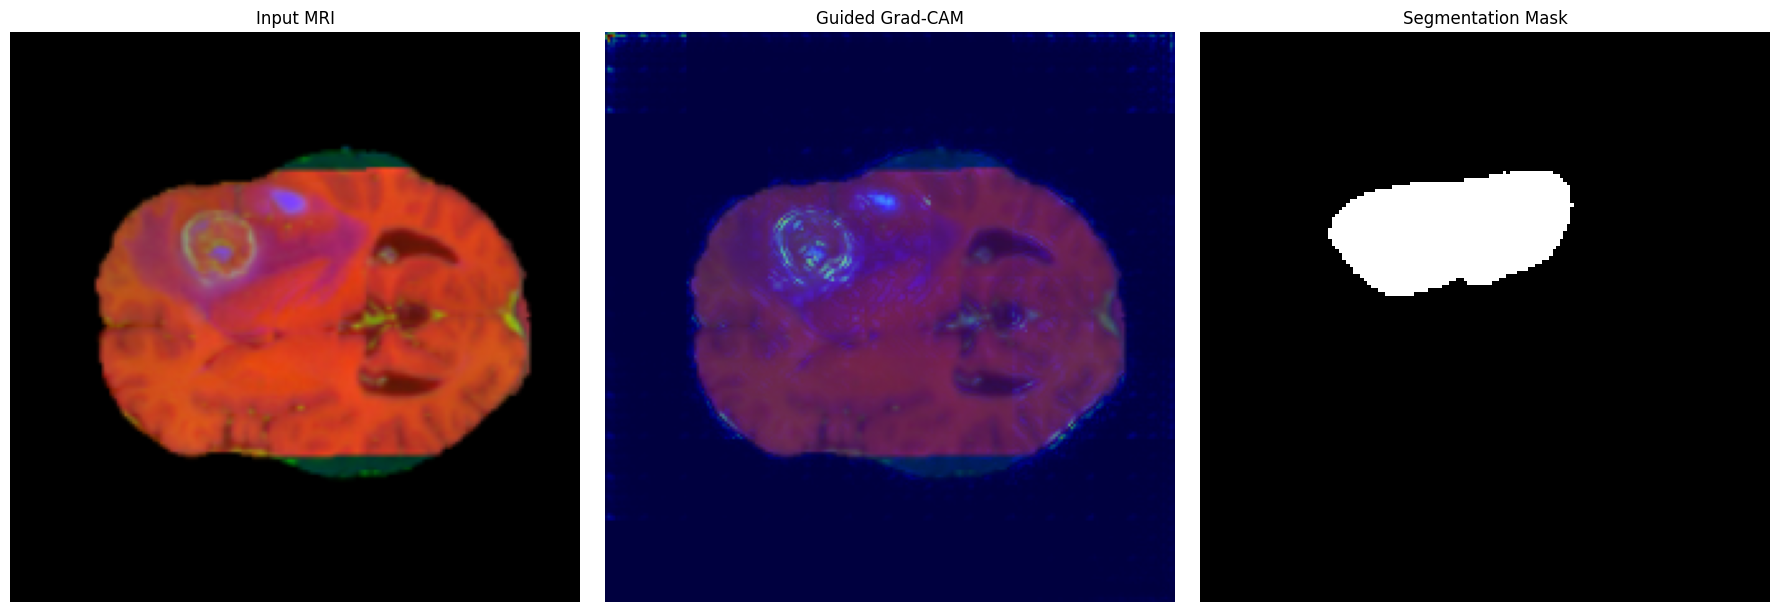


========== FINAL INFERENCE SUMMARY ==========
MRI Path        : /content/drive/MyDrive/Brats20_Project/Reduced/images/1217.npy
Tumor Class     : No Tumor
Tumor Volume    : 1766
Area Ratio      : 0.068984375
Survival Output : [2]
Fusion Length   : 2050


In [ ]:
# =========================================================
# COMPLETE SINGLE-SLICE INFERENCE PIPELINE
# Segmentation + Classification + Fusion + Survival + GradCAM
# =========================================================

import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from captum.attr import GuidedGradCam

# =========================================================
# DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model.eval().to(device)        # segmentation model
clf_model.eval().to(device)    # classification model

# =========================================================
# INPUT MRI (.npy)
# =========================================================
input_file = input("Enter full path to MRI .npy file: ").strip()

if not os.path.isfile(input_file):
    raise FileNotFoundError(input_file)

img_np = np.load(input_file)
print("Loaded MRI shape:", img_np.shape)

# =========================================================
# 1️⃣ SEGMENTATION
# =========================================================

# Convert to grayscale if needed
if img_np.ndim == 3 and img_np.shape[2] == 3:
    seg_img = img_np.mean(axis=-1)
else:
    seg_img = img_np

seg_img = cv2.resize(seg_img, (160, 160))
seg_img = (seg_img - seg_img.min()) / (seg_img.max() - seg_img.min() + 1e-8)
seg_img = seg_img.astype(np.float32)

seg_tensor = torch.from_numpy(seg_img).unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():
    seg_out = model(seg_tensor)

seg_mask = torch.sigmoid(seg_out)[0, 0].cpu().numpy()
seg_mask_binary = (seg_mask > 0.5).astype(np.uint8)

print("Segmentation done!")

# =========================================================
# 2️⃣ CLASSIFICATION
# =========================================================

cls_img = cv2.resize(img_np, (224, 224))
cls_img = (cls_img - cls_img.min()) / (cls_img.max() - cls_img.min() + 1e-8)

if cls_img.ndim == 2:
    cls_img = np.stack([cls_img]*3, axis=-1)

cls_img = cls_img.astype(np.float32)

cls_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

cls_tensor = cls_transform(cls_img).unsqueeze(0).to(device)

with torch.no_grad():
    features, logits = clf_model(cls_tensor, return_feature=True)

pred_label = logits.argmax(1).item()

class_map = {0: "No Tumor", 1: "LGG", 2: "HGG"}
pred_class = class_map[pred_label]

print("Classification done:", pred_class)

# =========================================================
# 3️⃣ FEATURE FUSION
# =========================================================

deep_feat = features.cpu().numpy().flatten()
tumor_volume = seg_mask_binary.sum()
area_ratio = tumor_volume / seg_mask_binary.size

fusion_feat = np.concatenate([
    deep_feat,
    np.array([tumor_volume, area_ratio], dtype=np.float32)
])

# =========================================================
# 4️⃣ SURVIVAL PREDICTION
# =========================================================

survival_pred = survival_model.predict(fusion_feat.reshape(1, -1))

print("Survival prediction done!")

# =============================
# 5) GRAD-CAM (FIXED)
# =============================
guided_gc = GuidedGradCam(
    model=clf_model,
    layer=clf_model.backbone.layer4[-1]
)

# IMPORTANT: Grad-CAM needs gradients
cls_tensor.requires_grad_(True)

attr = guided_gc.attribute(cls_tensor, target=pred_label)

# FIX: detach() before numpy()
heatmap = attr.abs().mean(dim=1)[0].detach().cpu().numpy()
heatmap = heatmap / (heatmap.max() + 1e-8)

print("Grad-CAM done!")

# =========================================================
# 6️⃣ VISUALIZATION
# =========================================================

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(cls_img, cmap="gray")
ax[0].set_title("Input MRI")

ax[1].imshow(cls_img, cmap="gray")
ax[1].imshow(heatmap, cmap="jet", alpha=0.5)
ax[1].set_title("Guided Grad-CAM")

ax[2].imshow(seg_mask_binary, cmap="gray")
ax[2].set_title("Segmentation Mask")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

# =========================================================
# 7️⃣ SUMMARY
# =========================================================

print("\n========== FINAL INFERENCE SUMMARY ==========")
print("MRI Path        :", input_file)
print("Tumor Class     :", pred_class)
print("Tumor Volume    :", tumor_volume)
print("Area Ratio      :", area_ratio)
print("Survival Output :", survival_pred)
print("Fusion Length   :", fusion_feat.shape[0])
print("============================================")